# ゼロから作る Deep Learning ❸ 輪読会
## 第 5 ステージ「DeZero で挑む」 ― ステップ 52 〜 56

### これまでの内容（ステップ 47 〜 51）

前回は、`softmax_cross_entropy` による多値分類、`Dataset` と `DataLoader` によるデータ処理、手書き数字の学習を扱った。学習ループの形は次のように整った。

```python
y = model(x)
loss = F.softmax_cross_entropy(y, t)
model.cleargrads()
loss.backward()
optimizer.update()
```

第 5 ステージでは、この仕組みを実用的な機能と画像向けの演算へ広げる。今回の前半は **GPU・重みの保存・Dropout**、後半は **CNN の計算の仕組み**である。

### 今回の目標

| ステップ | テーマ | 到達点 |
|---|---|---|
| 52 | GPU 対応 | NumPy と CuPy を切り替え、データとモデルを同じデバイスで計算する |
| 53 | モデルの保存と読み込み | パラメータを保存し、別のモデルで同じ予測を再現する |
| 54 | Dropout とテストモード | 学習時と推論時の振る舞い、`no_grad()` との違いを理解する |
| 55 | CNN のメカニズム (1) | 畳み込み・パディング・ストライドを小さな配列で追う |
| 56 | CNN のメカニズム (2) | チャネル・バッチ・プーリングとテンソルの形状を理解する |


## 準備：DeZero パッケージを読み込む

ステップ 42〜46 の Notebook と同様に、リポジトリの `dezero` パッケージを読み込む。前の Notebook を実行しておく必要はない。完成版のパッケージを使いつつ、新しく登場する仕組みは小さな実装でも確認する。**★ 印**は、そのステップの主要な追加箇所を表す。

リポジトリ直下で `uv sync` を実行してから `uv run jupyter lab` で開き、Python 3 カーネルで上から順に実行する。追加のスクリプトを実行するときは `python3` を使う。作業ディレクトリはリポジトリ直下・`notebooks/` のどちらでもよい。

- 標準設定はダウンロード不要のスパイラルデータを使う。GPU がなくても最後まで実行できる。
- ステップ 52 の `USE_MNIST = True` で書籍と同じ MNIST の学習を試せる。初回はデータのダウンロードが必要になる。
- GPU の実演には、環境に合う CuPy と利用可能な CUDA GPU が必要である。
- ステップ 55〜56 は NumPy で順伝播の仕組みを確認する。DeZero の畳み込みの本格的な実装は次回のステップ 57 以降で扱う。


In [1]:
import sys
import time
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np


current_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in (current_dir, *current_dir.parents)
     if (path / "dezero").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("dezero ディレクトリを含むリポジトリが見つかりません")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import dezero
from dezero import Config, DataLoader, Function, Variable, no_grad, test_mode
from dezero import cuda, optimizers
from dezero.models import MLP, Model
import dezero.functions as F
import dezero.layers as L


np.random.seed(52)
np.set_printoptions(precision=4, suppress=True)
print("repository:", repo_root)
print("NumPy:", np.__version__)


repository: /home/user/deep-learning-from-scratch-3
NumPy: 1.26.4


---
# ステップ 52：GPU 対応

## 52.1 NumPy と CuPy

GPU は多数の演算を並列に行う。大きな行列積を繰り返すニューラルネットワークでは高速化が期待できるが、小さな計算ではデータ転送や実行準備の時間が支配的になることもある。

CPU 上の配列には NumPy、GPU 上の配列には CuPy を使う。CuPy は NumPy に似た配列演算を提供するため、使うモジュールを `xp` という名前で受け取ると共通の式を書ける。

| 役割 | CPU | GPU |
|---|---|---|
| 配列 | `numpy.ndarray` | `cupy.ndarray` |
| 配列を作る | `np.array(...)` | `cp.array(...)` |
| 演算モジュールを得る | `cuda.get_array_module(x)` → NumPy | 同じ呼び出し → CuPy |
| CPU へ転送 | `cuda.as_numpy(x)` | 同じ呼び出しで GPU から転送 |
| GPU へ転送 | `cuda.as_cupy(x)` | 同じ呼び出しで CuPy 配列を得る |

`cuda.gpu_enable` が調べるのは **CuPy を import できたか**である。ここでは小さな GPU 演算まで試し、実際に計算できるか確認する。

Linux / WSL で uv からインストールした CUDA 12 ライブラリは、次のセルで直接読み込む。この Notebook では Jupyter 起動前の `LD_LIBRARY_PATH` 設定は不要である。CuPy の初期化に一度失敗したカーネルでは状態が残ることがあるため、修正後はカーネルを再起動して上から実行する。


In [2]:
# Linux / WSL の uv 環境に入れた CUDA 12 の共有ライブラリを読み込む。
# 起動済みの Jupyter では LD_LIBRARY_PATH の後付け変更が効かないため、
# 現在のカーネルのパッケージから絶対パスを求めて直接ロードする。
import ctypes
from importlib.metadata import PackageNotFoundError, distribution


def load_uv_cuda_libraries():
    if sys.platform != "linux":
        return []
    try:
        distribution("cupy-cuda12x")
    except PackageNotFoundError:
        return []  # システムの CUDA や、別の CUDA 版 CuPy はそのまま使う

    libraries = [
        ("nvidia-cuda-runtime-cu12", "cuda_runtime", "libcudart.so.12"),
        ("nvidia-cuda-nvrtc-cu12", "cuda_nvrtc", "libnvrtc.so.12"),
        ("nvidia-nvjitlink-cu12", "nvjitlink", "libnvJitLink.so.12"),
        ("nvidia-curand-cu12", "curand", "libcurand.so.10"),
        ("nvidia-cublas-cu12", "cublas", "libcublasLt.so.12"),
        ("nvidia-cublas-cu12", "cublas", "libcublas.so.12"),
        ("nvidia-cufft-cu12", "cufft", "libcufft.so.11"),
        ("nvidia-cusparse-cu12", "cusparse", "libcusparse.so.12"),
        ("nvidia-cusolver-cu12", "cusolver", "libcusolver.so.11"),
    ]
    handles = []
    for package, directory, filename in libraries:
        try:
            dist = distribution(package)
        except PackageNotFoundError:
            continue
        library_path = dist.locate_file(f"nvidia/{directory}/lib/{filename}")
        # 依存ライブラリを先にロードし、後から読むライブラリにも公開する。
        handles.append(ctypes.CDLL(str(library_path), mode=ctypes.RTLD_GLOBAL))
    return handles


gpu_available = False
gpu_status = "CuPy がないため CPU を使います"
if cuda.gpu_enable:
    try:
        cuda_library_handles = load_uv_cuda_libraries()
        cp = cuda.cupy
        if cp.cuda.runtime.getDeviceCount() > 0:
            probe = cp.arange(3, dtype=cp.float32)
            np.testing.assert_array_equal(cuda.as_numpy(probe * probe), [0, 1, 4])
            cp.cuda.get_current_stream().synchronize()
            gpu_available = True
            gpu_status = "GPU で配列演算を実行できました"
        else:
            gpu_status = "GPU が見つからないため CPU を使います"
    except Exception as error:
        gpu_status = f"GPU を利用できないため CPU を使います: {type(error).__name__}: {error}"

print("CuPy import:", cuda.gpu_enable)
print(gpu_status)

# ★ Step 52：配列の置き場所に応じて演算モジュールを選ぶ
array_cpu = np.array([1.0, 2.0, 3.0], dtype=np.float32)
xp = cuda.get_array_module(array_cpu)
print("CPU:", xp.__name__, xp.sum(array_cpu ** 2))
if gpu_available:
    array_gpu = cuda.as_cupy(array_cpu)
    xp = cuda.get_array_module(array_gpu)
    result_gpu = xp.sum(array_gpu ** 2)
    print("GPU:", xp.__name__, cuda.as_numpy(result_gpu))
    np.testing.assert_allclose(cuda.as_numpy(result_gpu), 14.0)


CuPy import: True
GPU で配列演算を実行できました
CPU: numpy 14.0
GPU: cupy 14.0


## 52.2 自動微分を GPU に対応させる

計算グラフをたどる仕組みはそのままで、配列を作る・操作する部分を対応させる。リポジトリの `Variable` は NumPy / CuPy の配列を受け取り、逆伝播の最初の勾配も対応するモジュールの `ones_like` で作る。

例として、$y=sum_i x_i^2$ を計算する `Function` を作る。順伝播では `xp.sum` を使い、逆伝播は DeZero の演算で $\partial y/\partial x_i=2x_i$ を表す。同じ関数を両方の配列に使える。


In [3]:
class SumSquares(Function):
    def forward(self, x):
        xp = cuda.get_array_module(x)  # ★ Step 52：np 固定から xp へ
        return xp.sum(x ** 2)

    def backward(self, gy):
        x, = self.inputs
        return 2 * x * gy


devices = [("CPU", np)]
if gpu_available:
    devices.append(("GPU", cuda.cupy))

for device_name, xp in devices:
    x_52 = Variable(xp.array([1.0, 2.0, 3.0], dtype=xp.float32))
    y_52 = SumSquares()(x_52)
    y_52.backward()
    print(device_name, "y =", cuda.as_numpy(y_52), "grad =", cuda.as_numpy(x_52.grad))
    np.testing.assert_allclose(cuda.as_numpy(y_52), 14.0)
    np.testing.assert_allclose(cuda.as_numpy(x_52.grad), [2.0, 4.0, 6.0])


CPU y = 14.0 grad = [2. 4. 6.]
GPU y = 14.0 grad = [2. 4. 6.]


## 52.3 データとモデルの置き場所をそろえる

`Variable.to_gpu()` はその変数のデータを、`model.to_gpu()` はモデル内のパラメータのデータを GPU に移す。`DataLoader.to_gpu()` は、取り出すミニバッチを CuPy 配列にする。**入力だけを移しても、重みが CPU に残っていれば一緒に演算できない。**

```python
train_loader.to_gpu()
model.to_gpu()
```

このリポジトリでは `to_cpu()` / `to_gpu()` が移すのは `.data` であり、既存の `.grad` は移さない。学習前に配置を決め、学習後に切り替えるときは `cleargrads()` で古い勾配を消しておく。Momentum や Adam の内部状態を持ったまま切り替えるには、その状態の扱いも必要になる。

## 52.4 学習ループと時間計測

標準設定では、前回使ったスパイラルデータと小さい MLP を使う。`USE_MNIST = True` にすると、`steps/step52.py` と同じ MNIST・隠れ層 1000・5 エポックの設定になる。CPU では時間がかかるため、まず標準設定で動作を確かめる。

GPU の演算は非同期に進むため、時間計測の前後で同期する。ここで測るのはデータ取得や損失の集計も含む **1 エポックの経過時間**であり、CPU / GPU の公平な速度比較ではない。


In [4]:
USE_MNIST = False
USE_GPU = gpu_available  # False にすると GPU がある環境でも CPU で実行

if USE_MNIST:
    train_set_52 = dezero.datasets.MNIST(train=True)
    output_sizes_52 = (1000, 10)
    max_epoch_52, batch_size_52, learning_rate_52 = 5, 100, 0.01
else:
    train_set_52 = dezero.datasets.Spiral(train=True)
    output_sizes_52 = (30, 3)
    max_epoch_52, batch_size_52, learning_rate_52 = 40, 30, 1.0

np.random.seed(52)
train_loader_52 = DataLoader(train_set_52, batch_size=batch_size_52)
model_52 = MLP(output_sizes_52)
optimizer_52 = optimizers.SGD(lr=learning_rate_52).setup(model_52)

if USE_GPU:
    cuda.cupy.random.seed(52)
    train_loader_52.to_gpu()  # ★ Step 52：ミニバッチを GPU 配列にする
    model_52.to_gpu()         # ★ Step 52：モデルも同じデバイスへ


def synchronize_device():
    if USE_GPU:
        cuda.cupy.cuda.get_current_stream().synchronize()


# Linear の重みは最初の入力から形状とデバイスを決める。
sample_x_52, _ = train_set_52[0]
warmup_x_52 = np.asarray(sample_x_52)[None, :]
if USE_GPU:
    warmup_x_52 = cuda.as_cupy(warmup_x_52)
with no_grad():
    model_52(warmup_x_52)
synchronize_device()

loss_history_52, elapsed_history_52 = [], []
print("dataset:", type(train_set_52).__name__, "device:", "GPU" if USE_GPU else "CPU")
for epoch in range(max_epoch_52):
    synchronize_device()
    start = time.perf_counter()
    sum_loss = 0.0

    for x_batch, t_batch in train_loader_52:
        y_batch = model_52(x_batch)
        loss = F.softmax_cross_entropy(y_batch, t_batch)
        model_52.cleargrads()
        loss.backward()
        optimizer_52.update()
        sum_loss += float(cuda.as_numpy(loss)) * len(t_batch)

    synchronize_device()  # ★ Step 52：GPU の完了を待ってから時間を読む
    elapsed = time.perf_counter() - start
    average_loss = sum_loss / len(train_set_52)
    loss_history_52.append(average_loss)
    elapsed_history_52.append(elapsed)
    if epoch == 0 or (epoch + 1) % 10 == 0 or USE_MNIST:
        print(f"epoch {epoch + 1:2d}: loss={average_loss:.4f}, time={elapsed:.4f} s")

assert np.isfinite(loss_history_52).all()


dataset: Spiral device: GPU
epoch  1: loss=1.7699, time=1.2553 s
epoch 10: loss=0.8111, time=0.0174 s
epoch 20: loss=0.7431, time=0.0188 s
epoch 30: loss=0.7427, time=0.0175 s
epoch 40: loss=0.7174, time=0.0174 s


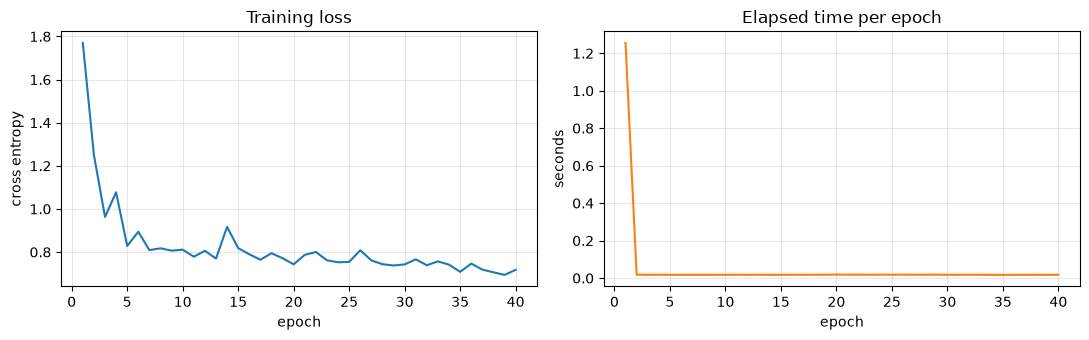

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
epochs_52 = np.arange(1, max_epoch_52 + 1)
axes[0].plot(epochs_52, loss_history_52)
axes[0].set(xlabel="epoch", ylabel="cross entropy", title="Training loss")
axes[1].plot(epochs_52, elapsed_history_52, color="tab:orange")
axes[1].set(xlabel="epoch", ylabel="seconds", title="Elapsed time per epoch")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


> **ステップ 52 のまとめ**
>
> - NumPy / CuPy の違いを配列操作の部分に集め、計算グラフと学習ループを共通化する。
> - 入力・ラベル・モデルのパラメータを同じデバイスにそろえる。
> - `Linear` の遅延初期化では、最初の入力に合うデバイスで重みが作られる。
> - GPU の時間計測では同期が必要。小さなデータで必ず速くなるとは限らない。


---
# ステップ 53：モデルの保存と読み込み

## 53.1 配列を保存する

学習の結果は各レイヤの重み $W$ とバイアス $b$ に入っている。それらを保存すれば、次回は学習をやり直さず予測できる。

NumPy の `np.savez_compressed` は、複数の配列を名前付きで 1 個の `.npz` ファイルに保存する。`np.load` の結果から名前で取り出せる。デモは一時ディレクトリ内で行い、セル終了時にファイルを片付ける。


In [6]:
with TemporaryDirectory(prefix="dezero_step53_arrays_") as work_dir:
    array_path_53 = Path(work_dir) / "arrays.npz"
    weights_53 = np.arange(6, dtype=np.float32).reshape(2, 3)
    bias_53 = np.zeros(3, dtype=np.float32)
    np.savez_compressed(array_path_53, W=weights_53, b=bias_53)
    with np.load(array_path_53, allow_pickle=False) as archive:
        print("保存した名前:", archive.files)
        print("読み込んだ W:\n", archive["W"])
        np.testing.assert_array_equal(archive["W"], weights_53)
        np.testing.assert_array_equal(archive["b"], bias_53)


保存した名前: ['W', 'b']
読み込んだ W:
 [[0. 1. 2.]
 [3. 4. 5.]]


## 53.2 入れ子の Layer に名前を付ける

`MLP` は `l0`、`l1` という子レイヤを持ち、それぞれが `W` と `b` を持つ。単に `W` と名付けると衝突するため、`l0/W`、`l1/W` のように親からの経路をキーにする。

```text
MLP
├── l0 ── W, b   →   l0/W, l0/b
└── l1 ── W, b   →   l1/W, l1/b
```

`Layer._flatten_params` の要点を小さな関数にすると次のようになる。`_params` を使うのは内部の仕組みを観察するためであり、通常の保存では `model.save_weights()` を呼ぶだけでよい。


In [7]:
def flatten_params_demo(layer, parent_key=""):
    result = {}
    for name in sorted(layer._params):
        obj = getattr(layer, name)
        key = f"{parent_key}/{name}" if parent_key else name
        if isinstance(obj, dezero.Layer):
            result.update(flatten_params_demo(obj, key))  # ★ Step 53：子へ再帰
        else:
            result[key] = obj
    return result


params_53 = flatten_params_demo(model_52)
for name, parameter in params_53.items():
    print(f"{name:6s}: shape={parameter.shape}")


l0/W  : shape=(2, 30)
l0/b  : shape=(30,)
l1/W  : shape=(30, 3)
l1/b  : shape=(3,)


## 53.3 別のモデルへ読み込み、予測の一致を確認する

`save_weights` はパラメータを CPU に移してから `.npz` に保存する。`load_weights` は、同じ経路のパラメータに配列を代入する。モデルの構造や活性化関数は保存されないため、**同じ構造・同じ活性化関数のモデルを自分で作る**必要がある。

このリポジトリでは `save_weights` の呼び出しによって元のモデルも CPU 配置になる。また、遅延初期化の重みが `None` のままでは有効な重みとして保存できない。ここではステップ 52 で学習済みのモデルを使い、CPU 上で保存前後の出力を比較する。


In [8]:
# 配置を変える前に、前のデバイスで計算した勾配を消しておく。
model_52.cleargrads()
model_52.to_cpu()
preview_x_53 = np.stack([train_set_52[i][0] for i in range(8)])
with test_mode(), no_grad():
    prediction_before_53 = model_52(preview_x_53).data.copy()

with TemporaryDirectory(prefix="dezero_step53_model_") as work_dir:
    weights_path_53 = Path(work_dir) / "my_mlp.npz"
    model_52.save_weights(weights_path_53)  # ★ Step 53：パラメータを保存

    with np.load(weights_path_53, allow_pickle=False) as archive:
        print("保存したキー:", sorted(archive.files))
        assert set(archive.files) == set(params_53)
    print("ファイルサイズ:", weights_path_53.stat().st_size, "bytes")

    restored_model_53 = MLP(output_sizes_52)
    restored_model_53.load_weights(weights_path_53)  # ★ Step 53：別のモデルへ復元
    with test_mode(), no_grad():
        prediction_after_53 = restored_model_53(preview_x_53).data.copy()

np.testing.assert_allclose(prediction_after_53, prediction_before_53, rtol=0, atol=0)
print("保存前後の予測の最大差:", np.max(np.abs(prediction_before_53 - prediction_after_53)))
print("予測クラス:", prediction_after_53.argmax(axis=1))
print("ファイル削除後も、読み込んだモデルはメモリ上で利用できます")


保存したキー: ['l0/W', 'l0/b', 'l1/W', 'l1/b']
ファイルサイズ: 1523 bytes
保存前後の予測の最大差: 0.0
予測クラス: [2 1 0 1 1 2 0 1]
ファイル削除後も、読み込んだモデルはメモリ上で利用できます


## 53.4 学習を再開するときの違い

読み込んだモデルに Optimizer を設定すれば追加学習できる。ただし、この API が保存するのは **モデルのパラメータだけ**である。

| 保存されるもの | 保存されないもの |
|---|---|
| 各レイヤの重み・バイアス | モデルの構造・活性化関数 |
| パラメータ名と配列 | Momentum / Adam の内部状態、エポック数、乱数状態 |

SGD で 1 回追加学習してみる。ここでは状態を持たない SGD を新しく作る。GPU で再開する場合は、読み込んだモデルと DataLoader を再び `to_gpu()` する。


In [9]:
resume_optimizer_53 = optimizers.SGD(lr=learning_rate_52).setup(restored_model_53)
resume_t_53 = np.array([train_set_52[i][1] for i in range(len(preview_x_53))])
resumed_loss_53 = F.softmax_cross_entropy(restored_model_53(preview_x_53), resume_t_53)
restored_model_53.cleargrads()
resumed_loss_53.backward()
resume_optimizer_53.update()

with test_mode(), no_grad():
    updated_loss_53 = F.softmax_cross_entropy(restored_model_53(preview_x_53), resume_t_53)
print(f"同じミニバッチの損失: {float(resumed_loss_53.data):.4f} → {float(updated_loss_53.data):.4f}")


同じミニバッチの損失: 0.7042 → 0.6334


手元に重みを残す場合は、保存先を決めて次のように使う。

```python
model_52.save_weights("my_mlp.npz")

model = MLP(output_sizes_52)
model.load_weights("my_mlp.npz")
```

> **ステップ 53 のまとめ**
>
> - `np.savez_compressed` で複数の配列を名前付きで保存できる。
> - 子レイヤをたどり、`l0/W` のような経路でパラメータ名を区別する。
> - 同じ構造のモデルに読み込めば、同じ入力に対する予測を再現できる。
> - 重みの保存は、学習状態全体の保存とは異なる。


---
# ステップ 54：Dropout とテストモード

## 54.1 Dropout の考え方

訓練データに合いすぎて未知のデータで性能が落ちることを過学習という。Dropout は、学習時にニューロンの出力をランダムに 0 にする正則化手法で、特定の出力の組み合わせに依存しすぎることを抑える。

落とす確率を $p$、残すかどうかのマスクを $m_i\sim\mathrm{Bernoulli}(1-p)$ とすると、単に $m_i x_i$ にした出力の期待値は $(1-p)x_i$ になる。学習時と推論時のスケールを合わせるには、次の 2 通りがある。

| 方式 | 学習時 | 推論時 |
|---|---|---|
| 推論時に調整 | $m_i x_i$ | $(1-p)x_i$ |
| 学習時に調整（DeZero） | $m_i x_i/(1-p)$ | $x_i$ |

DeZero は後者の **inverted dropout** を使う。$p=0.5$ なら学習時に約半分を 0、残りを 2 倍にする。

$$\mathbb{E}\left[\frac{m_i x_i}{1-p}\right]
=\frac{(1-p)x_i}{1-p}=x_i$$

期待値がそろうのは、この Dropout の出力についてである。後ろに非線形な層を重ねたネットワーク全体の予測まで厳密に一致するという意味ではない。


## 54.2 DeZero の演算を組み合わせて実装する

マスクの生成には NumPy / CuPy を使い、掛け算と割り算には `Variable` の演算を使う。新しい逆伝播クラスを作らなくても、既存の自動微分が働く。次は `F.dropout` の要点を、引数の範囲チェックを加えて書いた学習用の実装である。


In [10]:
def dropout_demo(x, dropout_ratio=0.5):
    if not 0.0 <= dropout_ratio < 1.0:
        raise ValueError("dropout_ratio は 0 以上 1 未満にしてください")
    x = dezero.as_variable(x)
    if Config.train:
        xp = cuda.get_array_module(x)
        mask = xp.random.rand(*x.shape) > dropout_ratio
        scale = xp.array(1.0 - dropout_ratio, dtype=x.dtype)
        return x * mask / scale  # ★ Step 54：学習時にスケールを補正
    return x                    # ★ Step 54：推論時はそのまま通す


np.random.seed(54)
x_54 = Variable(np.ones(12, dtype=np.float32))
y_train_54 = dropout_demo(x_54)
y_train_54.sum().backward()
with test_mode():
    y_test_54 = dropout_demo(x_54)

print("入力:  ", x_54.data)
print("学習時:", y_train_54.data)
print("勾配:  ", x_54.grad.data)
print("推論時:", y_test_54.data)
np.testing.assert_array_equal(y_test_54.data, x_54.data)
np.testing.assert_array_equal(x_54.grad.data, y_train_54.data)

# 同じ乱数シードなら、パッケージ版と同じマスク・同じ出力になる。
np.random.seed(540)
demo_output_54 = dropout_demo(np.ones(20, dtype=np.float32))
np.random.seed(540)
package_output_54 = F.dropout(np.ones(20, dtype=np.float32))
np.testing.assert_array_equal(demo_output_54.data, package_output_54.data)


入力:   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
学習時: [0. 0. 0. 2. 0. 2. 2. 2. 2. 0. 0. 0.]
勾配:   [0. 0. 0. 2. 0. 2. 2. 2. 2. 0. 0. 0.]
推論時: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


順伝播で消えた位置には、逆伝播でも勾配が流れない。残った位置の勾配は $1/(1-p)$ 倍になる。上の例では入力がすべて 1、出力の和を微分しているので、出力と勾配が同じ 0 / 2 の並びになる。

1 回のマスクで出力の平均がちょうど 1 になるとは限らない。多数の試行で平均を取ると、期待値に近づくことを確認する。


0 になった割合: 0.4983666666666667
出力の平均: 1.0032667 （期待値は 1）


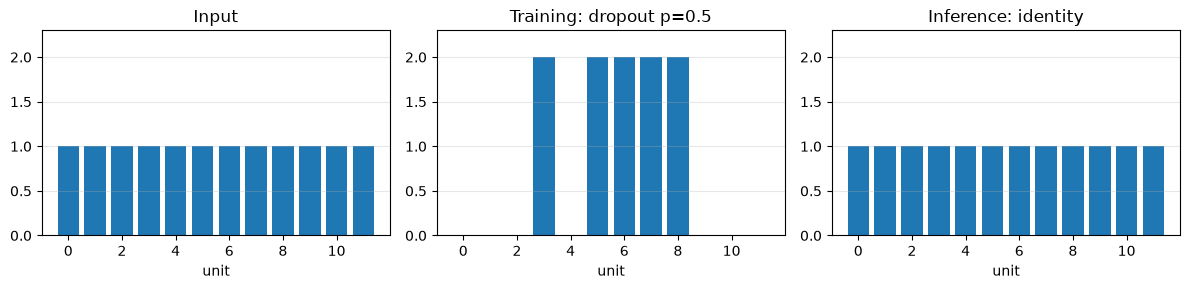

In [11]:
np.random.seed(541)
dropout_ratio_54 = 0.5
with no_grad():
    repeated_54 = dropout_demo(np.ones((5000, 12), dtype=np.float32), dropout_ratio_54).data
print("0 になった割合:", (repeated_54 == 0).mean())
print("出力の平均:", repeated_54.mean(), "（期待値は 1）")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, values, title in zip(
    axes,
    [x_54.data, y_train_54.data, y_test_54.data],
    ["Input", "Training: dropout p=0.5", "Inference: identity"],
):
    ax.bar(np.arange(len(values)), values)
    ax.set(title=title, xlabel="unit", ylim=(0, 2.3))
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 54.3 `test_mode()` と `no_grad()` の違い

`Config.train` はレイヤの振る舞い、`Config.enable_backprop` は計算グラフを作るかどうかを制御する。どちらも `using_config` が一時的に値を変更し、`with` を抜けると元に戻す。

| コンテキスト（既定の学習設定から入る場合） | Dropout | 計算グラフ |
|---|---|---|
| なし | 有効 | 作る |
| `no_grad()` | 有効 | 作らない |
| `test_mode()` | 無効 | 作る |
| `test_mode(), no_grad()` | 無効 | 作らない |

**`no_grad()` だけでは Dropout は無効にならない。** 通常の推論では 2 つを組み合わせる。推論モードでの勾配が必要なら `test_mode()` だけを使える。


In [12]:
from contextlib import ExitStack


original_flags_54 = (Config.train, Config.enable_backprop)
contexts_54 = [
    ("通常", ()),
    ("no_grad", (no_grad,)),
    ("test_mode", (test_mode,)),
    ("両方", (test_mode, no_grad)),
]
for label, factories in contexts_54:
    with ExitStack() as stack:
        for factory in factories:
            stack.enter_context(factory())
        # sum を含めると、Dropout が恒等写像でもグラフ作成の有無を確認できる。
        mode_output_54 = F.sum(dropout_demo(np.ones(12, dtype=np.float32)))
        print(f"{label:9s}: train={Config.train}, "
              f"enable_backprop={Config.enable_backprop}, "
              f"creatorあり={mode_output_54.creator is not None}")
        assert (mode_output_54.creator is not None) == Config.enable_backprop

assert (Config.train, Config.enable_backprop) == original_flags_54
print("with を抜けると設定が元に戻ります:", original_flags_54)


通常       : train=True, enable_backprop=True, creatorあり=True
no_grad  : train=True, enable_backprop=False, creatorあり=False
test_mode: train=False, enable_backprop=True, creatorあり=True
両方       : train=False, enable_backprop=False, creatorあり=False
with を抜けると設定が元に戻ります: (True, True)


## 54.4 MLP に組み込む

隠れ層の活性化後に Dropout を挟む。最後の層はクラスごとのスコアをそのまま返す。以下では小さな入力で学習の 1 反復と推論を確認する。過学習を抑えられたかどうかを調べるには、別途、訓練データと検証データで学習曲線を比較する必要がある。


In [13]:
class DropoutMLP(Model):
    def __init__(self, hidden_size, out_size, dropout_ratio=0.5):
        super().__init__()
        self.l1 = L.Linear(hidden_size)
        self.l2 = L.Linear(out_size)
        self.dropout_ratio = dropout_ratio

    def forward(self, x):
        h = F.relu(self.l1(x))
        h = F.dropout(h, self.dropout_ratio)  # ★ Step 54：隠れ層に Dropout
        return self.l2(h)


np.random.seed(542)
model_54 = DropoutMLP(hidden_size=20, out_size=3)
optimizer_54 = optimizers.SGD(lr=0.1).setup(model_54)
batch_x_54 = np.random.randn(8, 2).astype(np.float32)
batch_t_54 = np.arange(8) % 3
loss_54 = F.softmax_cross_entropy(model_54(batch_x_54), batch_t_54)
model_54.cleargrads()
loss_54.backward()
optimizer_54.update()

with test_mode(), no_grad():  # ★ Step 54：推論の設定は外側で切り替える
    prediction_54_a = model_54(batch_x_54).data
    prediction_54_b = model_54(batch_x_54).data

np.testing.assert_array_equal(prediction_54_a, prediction_54_b)
print("1 反復の学習損失:", float(loss_54.data))
print("推論を 2 回行った最大差:", np.max(np.abs(prediction_54_a - prediction_54_b)))


1 反復の学習損失: 1.6923840045928955
推論を 2 回行った最大差: 0.0


> **ステップ 54 のまとめ**
>
> - Dropout は、学習時に出力をランダムに 0 にする正則化手法である。
> - DeZero は学習時に $1/(1-p)$ 倍し、推論時にはそのまま通す。
> - マスクを掛ける演算にも自動微分が働く。
> - `test_mode()` と `no_grad()` は異なる設定を操作する。通常の推論には両方を使う。


---
# ステップ 55：CNN のメカニズム (1)

## 55.1 全結合層から畳み込み層へ

これまでの全結合層では、画像を 1 本のベクトルへ並べてから $y=xW+b$ を計算した。画素の値は残るが、**どの画素が隣り合うかという構造を層の設計に直接使っていない**。

畳み込みニューラルネットワーク (Convolutional Neural Network; CNN) は、画像の近い場所どうしをまとめて調べる**畳み込み層**を使う。同じフィルタを画像の各位置へ動かし、局所的な模様への反応を並べた**特徴マップ**を作る。

| 観点 | 全結合層 | 畳み込み層 |
|---|---|---|
| 1 個の出力が参照する範囲 | 入力の全要素 | フィルタが重なる局所領域 |
| 重みの使い方 | 出力ごとに異なる重み | 同じフィルタを空間方向に共有 |
| 画像の扱い | 通常は平坦化して渡す | 縦・横・チャネルの軸を保つ |
| パラメータ数 | 入力・出力の要素数に依存 | チャネル数・フィルタサイズに依存 |

ここからの NumPy 実装は計算の仕組みを見るための順伝播専用コードである。自動微分への組み込みと効率化は、ステップ 57 以降で扱う。

## 55.2 2 次元の畳み込みを手で計算する

まずは入力もフィルタも 2 次元とし、ストライド 1、パディングなし、バイアス 0 を考える。入力の小領域とフィルタを要素ごとに掛け、その総和を出力の 1 要素とする。

$$y_{i,j}=\sum_{u=0}^{K_H-1}\sum_{v=0}^{K_W-1}
 x_{i+u,j+v}w_{u,v}+b$$

入力の左上が $\begin{bmatrix}1&2\\5&6\end{bmatrix}$、フィルタが $\begin{bmatrix}1&0\\0&-1\end{bmatrix}$ なら、最初の出力は次のとおり。

$$1\times1+2\times0+5\times0+6\times(-1)=-5$$

CNN で通常「畳み込み」と呼ぶ演算ではフィルタを反転しない。数学でいう相互相関に相当するが、このノートブックでも CNN の慣例に合わせて畳み込みと呼ぶ。

In [14]:
x_55 = np.arange(1, 17, dtype=np.float64).reshape(4, 4)
kernel_55 = np.array([[1.0, 0.0], [0.0, -1.0]])
patch_55 = x_55[:2, :2]
products_55 = patch_55 * kernel_55  # ★ Step 55：対応する位置どうしを掛ける
first_output_55 = products_55.sum()  # ★ Step 55：足し合わせて出力 1 要素にする

print("input:\n", x_55)
print("first patch:\n", patch_55)
print("elementwise products:\n", products_55)
print("first output:", first_output_55)
assert first_output_55 == -5

input:
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]
first patch:
 [[1. 2.]
 [5. 6.]]
elementwise products:
 [[ 1.  0.]
 [ 0. -6.]]
first output: -5.0


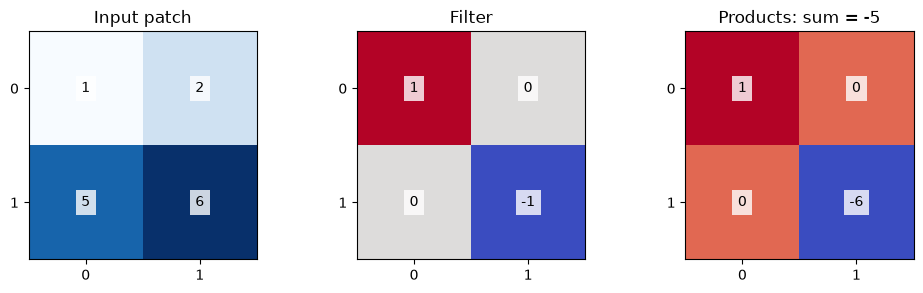

In [15]:
def show_matrix(ax, matrix, title, cmap="Blues"):
    """小さな 2 次元配列を、値の注記つきで表示する。"""
    ax.imshow(matrix, cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(np.arange(matrix.shape[1]))
    ax.set_yticks(np.arange(matrix.shape[0]))
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(
                col, row, f"{matrix[row, col]:g}", ha="center", va="center",
                color="black", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
            )


fig_55, axes_55 = plt.subplots(1, 3, figsize=(10, 3))
show_matrix(axes_55[0], patch_55, "Input patch")
show_matrix(axes_55[1], kernel_55, "Filter", cmap="coolwarm")
show_matrix(axes_55[2], products_55, "Products: sum = -5", cmap="coolwarm")
plt.tight_layout()
plt.show()

## 55.3 小さな NumPy 実装

フィルタを置く位置を二重ループで動かせば、特徴マップ全体が得られる。`np.pad` は画像の周囲へ 0 を付け、`stride` はフィルタを動かす幅を表す。ここでは、縦横に同じ整数のストライドとパディングを使う。

`get_conv_outsize` は `steps/step55.py` と同じ出力サイズの計算である。`conv2d_array` はそれを使って、このノートブック内で動作を確認するために追加する実装である。

In [16]:
def get_conv_outsize(input_size, kernel_size, stride, pad):
    # ★ Step 55：フィルタを置ける位置の数を求める
    return (input_size + 2 * pad - kernel_size) // stride + 1


def conv2d_array(x, kernel, stride=1, pad=0):
    """単一チャネル・バイアスなしの畳み込み（NumPy 順伝播版）。"""
    if x.ndim != 2 or kernel.ndim != 2:
        raise ValueError("x と kernel は 2 次元配列にしてください")
    if stride < 1 or pad < 0:
        raise ValueError("stride >= 1、pad >= 0 としてください")
    kh, kw = kernel.shape
    oh = get_conv_outsize(x.shape[0], kh, stride, pad)
    ow = get_conv_outsize(x.shape[1], kw, stride, pad)
    if min(oh, ow) < 1:
        raise ValueError("フィルタが入力より大きすぎます")
    padded = np.pad(x, ((pad, pad), (pad, pad)), mode="constant")
    y = np.zeros((oh, ow), dtype=np.result_type(x, kernel, np.float32))
    for row in range(oh):
        for col in range(ow):
            top, left = row * stride, col * stride
            patch = padded[top:top + kh, left:left + kw]
            y[row, col] = (patch * kernel).sum()  # ★ Step 55：重みを各位置で共有
    return y


y_55 = conv2d_array(x_55, kernel_55)
print("output shape:", y_55.shape)
print(y_55)
np.testing.assert_allclose(y_55, np.full((3, 3), -5.0))

output shape: (3, 3)
[[-5. -5. -5.]
 [-5. -5. -5.]
 [-5. -5. -5.]]


## 55.4 パディング・ストライドと出力サイズ

高さ $H$・幅 $W$ の入力へ、上下に $P_H$、左右に $P_W$ のゼロパディングを加える。フィルタの高さ・幅を $K_H,K_W$、移動幅を $S_H,S_W$ とすると、出力サイズは次のようになる。

$$O_H=\left\lfloor\frac{H+2P_H-K_H}{S_H}\right\rfloor+1,
\qquad
O_W=\left\lfloor\frac{W+2P_W-K_W}{S_W}\right\rfloor+1$$

- **パディング**：画像の周囲を補い、端にもフィルタを適用できるようにする。たとえば $3\times3$ のフィルタ、ストライド 1、パディング 1 なら縦横のサイズを保てる。
- **ストライド**：フィルタを一度に動かす距離。大きくすると出力の位置が間引かれ、通常は空間サイズが小さくなる。

分子がストライドで割り切れない場合は、フィルタがはみ出さずに置ける位置までを使うため、床関数で切り捨てる。この式は拡張率 (dilation) 1、両側に同じ量のパディングを加える場合の式である。

In [17]:
size_cases_55 = [(4, 3, 1, 0), (4, 3, 1, 1), (4, 3, 2, 1)]
print(" input  kernel  stride  pad  output")
for input_size_55, kernel_size_55, stride_55, pad_55 in size_cases_55:
    output_size_55 = get_conv_outsize(
        input_size_55, kernel_size_55, stride_55, pad_55
    )
    print(f"{input_size_55:6d}{kernel_size_55:8d}{stride_55:8d}"
          f"{pad_55:5d}{output_size_55:8d}")

# steps/step55.py の H=W=4, KH=KW=3, stride=1, pad=1 を確認
assert get_conv_outsize(4, 3, 1, 1) == 4
assert get_conv_outsize(4, 3, 2, 1) == 2

 input  kernel  stride  pad  output
     4       3       1    0       2
     4       3       1    1       4
     4       3       2    1       2


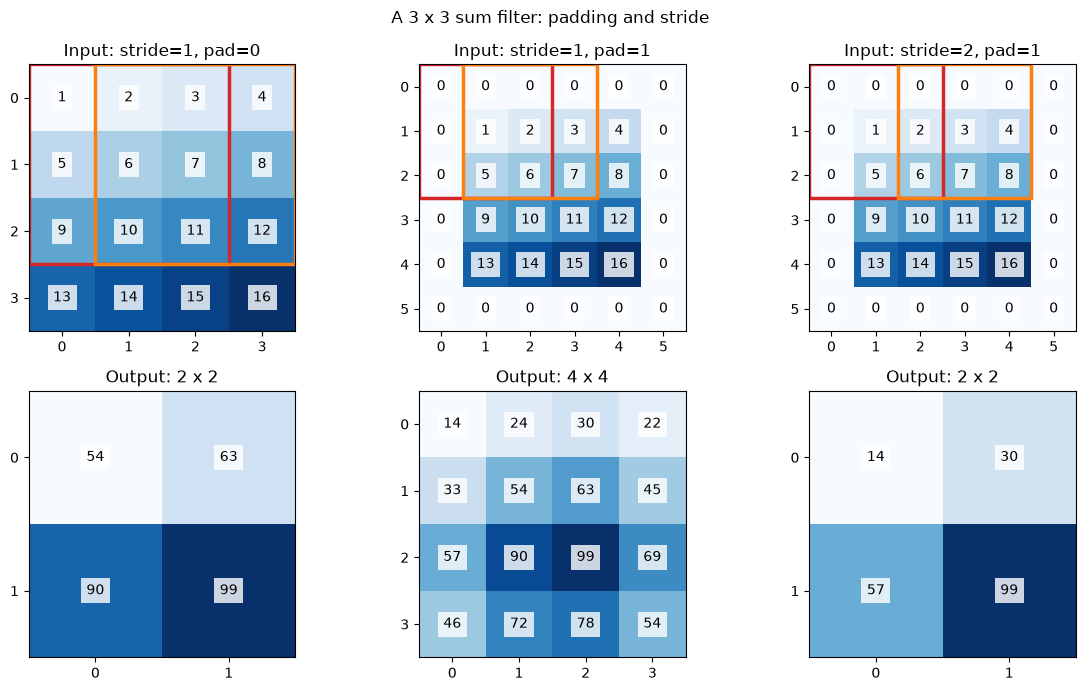

In [18]:
from matplotlib.patches import Rectangle


box_kernel_55 = np.ones((3, 3))
fig_55, axes_55 = plt.subplots(2, 3, figsize=(12, 7))
for index_55, (stride_55, pad_55) in enumerate([(1, 0), (1, 1), (2, 1)]):
    padded_55 = np.pad(x_55, pad_55)
    result_55 = conv2d_array(x_55, box_kernel_55, stride=stride_55, pad=pad_55)
    show_matrix(axes_55[0, index_55], padded_55,
                f"Input: stride={stride_55}, pad={pad_55}")
    # 赤枠が最初の窓、橙枠が横方向に 1 回動かした窓
    for left_55, color_55 in [(0, "tab:red"), (stride_55, "tab:orange")]:
        axes_55[0, index_55].add_patch(Rectangle(
            (left_55 - 0.5, -0.5), 3, 3, fill=False, edgecolor=color_55, linewidth=2.5
        ))
    show_matrix(axes_55[1, index_55], result_55,
                f"Output: {result_55.shape[0]} x {result_55.shape[1]}")
fig_55.suptitle("A 3 x 3 sum filter: padding and stride")
plt.tight_layout()
plt.show()

## 55.5 フィルタが作る特徴マップ

横方向の差を取るフィルタは縦の境界に、縦方向の差を取るフィルタは横の境界に反応する。以下では中央に長方形を置いた人工画像を使い、入力のどの場所が強く反応するかを見る。

同じフィルタを各位置へ使うため、模様の位置が変われば、対応する特徴マップの反応位置も変わる。ただし画像の端やストライドの影響があるので、どのような移動に対しても完全に同じ関係になるとは限らない。

この例のフィルタは人が決めている。CNN の学習では、フィルタの要素自体を損失の勾配から更新する。

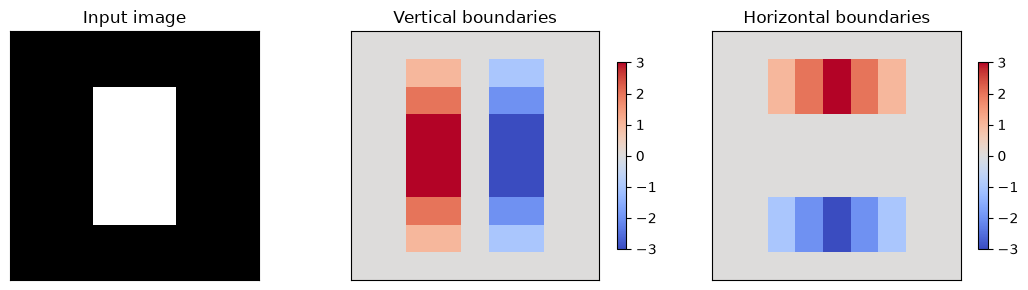

In [19]:
image_55 = np.zeros((9, 9))
image_55[2:7, 3:6] = 1
vertical_kernel_55 = np.array([[-1.0, 0.0, 1.0]] * 3)
horizontal_kernel_55 = vertical_kernel_55.T
vertical_map_55 = conv2d_array(image_55, vertical_kernel_55, pad=1)
horizontal_map_55 = conv2d_array(image_55, horizontal_kernel_55, pad=1)

fig_55, axes_55 = plt.subplots(1, 3, figsize=(11, 3))
axes_55[0].imshow(image_55, cmap="gray", vmin=0, vmax=1)
axes_55[0].set_title("Input image")
for ax_55, feature_55, title_55 in [
    (axes_55[1], vertical_map_55, "Vertical boundaries"),
    (axes_55[2], horizontal_map_55, "Horizontal boundaries"),
]:
    im_55 = ax_55.imshow(feature_55, cmap="coolwarm", vmin=-3, vmax=3)
    ax_55.set_title(title_55)
    fig_55.colorbar(im_55, ax=ax_55, shrink=0.75)
for ax_55 in axes_55:
    ax_55.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

> **ステップ 55 のまとめ**
>
> - 畳み込みは、局所領域とフィルタの要素積を足し合わせる演算である。
> - 同じ重みを空間方向に共有し、特徴の位置を保った特徴マップを作る。
> - パディングは画像の周囲を補い、ストライドはフィルタを動かす距離を決める。
> - 出力サイズは入力サイズ・フィルタサイズ・パディング・ストライドから計算できる。
> - 次はチャネルとバッチの軸を加え、実際の画像データの形状へ広げる。

---
# ステップ 56：CNN のメカニズム (2)

## 56.1 チャネル方向にも足し合わせる

カラー画像には RGB の 3 チャネルがある。入力が $(C,H,W)$ のとき、出力の 1 チャネルを作るフィルタは $(C,K_H,K_W)$ を持つ。**入力とフィルタのチャネル数は一致させる**。

各チャネルでステップ 55 と同じ計算を行い、その結果をチャネル方向へ合算する。バイアスは、合算後の各出力位置へ 1 回ずつ足す。

$$y_{i,j}=\sum_{c=0}^{C-1}\sum_{u=0}^{K_H-1}\sum_{v=0}^{K_W-1}
 x_{c,i+u,j+v}w_{c,u,v}+b$$

入力が 3 チャネルでも、フィルタが 1 個なら出力は 1 チャネルである。ここでは色画像ではなく、小さな数値配列を 3 枚重ねて合算を見えるようにする。`steps/step56.py` はコードのない説明のステップなので、以下の NumPy コードと図は理解を助けるための補足である。

In [20]:
x_channels_56 = np.stack([
    np.arange(1, 10, dtype=np.float64).reshape(3, 3),
    np.full((3, 3), 2.0),
    np.eye(3),
])
filter_channels_56 = np.stack([
    np.array([[1.0, 0.0], [0.0, -1.0]]),
    np.ones((2, 2)),
    np.array([[0.0, 1.0], [1.0, 0.0]]),
])
contributions_56 = np.stack([
    conv2d_array(x_channels_56[channel_56], filter_channels_56[channel_56])
    for channel_56 in range(3)
])
bias_56 = 0.5
y_single_56 = contributions_56.sum(axis=0) + bias_56  # ★ Step 56：チャネルを合算

print("input shape:", x_channels_56.shape)
print("one filter shape:", filter_channels_56.shape)
print("左上のチャネル別寄与:", contributions_56[:, 0, 0])
print("左上の出力:", y_single_56[0, 0])
print("output:\n", y_single_56)
np.testing.assert_allclose(contributions_56[:, 0, 0], [-4.0, 8.0, 0.0])
assert y_single_56[0, 0] == 4.5

input shape: (3, 3, 3)
one filter shape: (3, 2, 2)
左上のチャネル別寄与: [-4.  8.  0.]
左上の出力: 4.5
output:
 [[4.5 5.5]
 [5.5 4.5]]


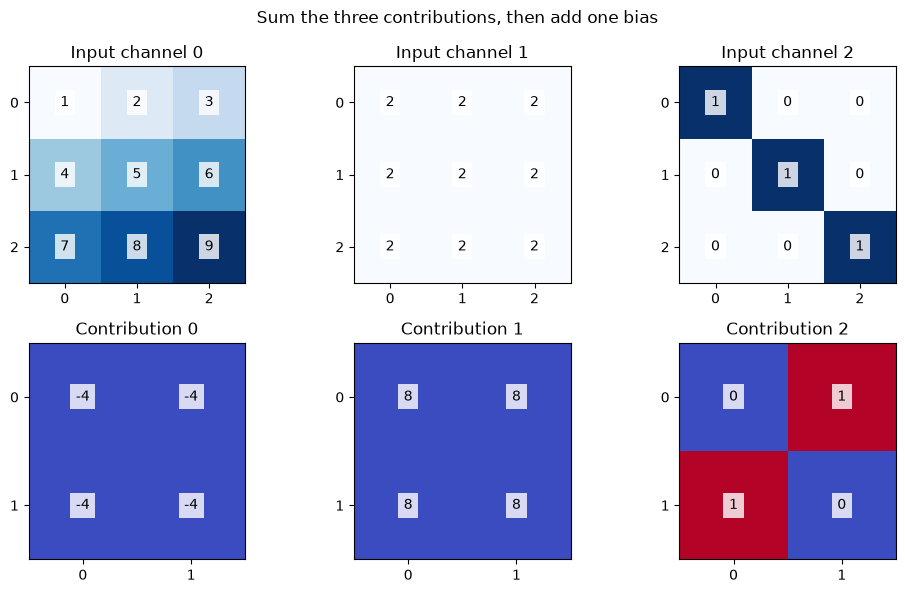

In [21]:
fig_56, axes_56 = plt.subplots(2, 3, figsize=(10, 6))
for channel_56 in range(3):
    show_matrix(axes_56[0, channel_56], x_channels_56[channel_56],
                f"Input channel {channel_56}")
    show_matrix(axes_56[1, channel_56], contributions_56[channel_56],
                f"Contribution {channel_56}", cmap="coolwarm")
fig_56.suptitle("Sum the three contributions, then add one bias")
plt.tight_layout()
plt.show()

## 56.2 フィルタを増やして出力チャネルを作る

フィルタを $O_C$ 個用意すると、それぞれが 1 枚の特徴マップを作り、出力は $O_C$ チャネルになる。DeZero は重みを次の順番で保持する。

$$W:\ (O_C,C,K_H,K_W),\qquad b:\ (O_C,)$$

各フィルタは入力の全チャネルを見る。バイアスは出力チャネルごとに 1 個あり、同じ出力チャネル内のすべての位置で共有する。したがって学習可能なパラメータ数は、バイアスありの場合、

$$O_C\times C\times K_H\times K_W+O_C$$

となる。入力の縦横サイズやバッチサイズを変えても、この個数は変わらない。

In [22]:
def conv2d_nchw_array(x, weight, bias=None, stride=1, pad=0):
    """NCHW 入力を扱う畳み込み。自動微分には対応しない説明用実装。"""
    n, channels, height, width = x.shape
    out_channels, filter_channels, kh, kw = weight.shape
    if channels != filter_channels:
        raise ValueError("入力とフィルタのチャネル数が一致していません")
    if bias is not None and bias.shape != (out_channels,):
        raise ValueError("bias の形状は (出力チャネル数,) にしてください")
    oh = get_conv_outsize(height, kh, stride, pad)
    ow = get_conv_outsize(width, kw, stride, pad)
    y = np.zeros((n, out_channels, oh, ow),
                 dtype=np.result_type(x, weight, np.float32))
    for batch in range(n):
        for out_channel in range(out_channels):
            for channel in range(channels):
                # ★ Step 56：各入力チャネルからの寄与を同じ出力へ足す
                y[batch, out_channel] += conv2d_array(
                    x[batch, channel], weight[out_channel, channel], stride, pad
                )
            if bias is not None:
                y[batch, out_channel] += bias[out_channel]
    return y

## 56.3 バッチを加える：NCHW

$N$ 枚の画像をまとめると、入力は **NCHW** の 4 次元配列になる。

| 軸 | 意味 | このあとの例 |
|---|---|---|
| $N$ | バッチ内の画像数 | 2 |
| $C$ | 入力チャネル数 | 3 |
| $H$ | 入力の高さ | 3 |
| $W$ | 入力の幅 | 3 |

同じ重みとバイアスを各画像に適用する。バッチ方向の値は足し合わせず、各画像の出力をそのまま並べる。

$$x:\ (N,C,H,W)\quad\longrightarrow\quad y:\ (N,O_C,O_H,O_W)$$

先ほどの画像と、全要素を 1 大きくした画像をバッチにする。フィルタは先ほどのものと符号を反転したものの 2 個を使う。

In [23]:
x_batch_56 = np.stack([x_channels_56, x_channels_56 + 1])
weights_56 = np.stack([filter_channels_56, -filter_channels_56])
biases_56 = np.array([0.5, -0.5])
y_batch_56 = conv2d_nchw_array(x_batch_56, weights_56, biases_56)

print("input shape :", x_batch_56.shape)
print("weight shape:", weights_56.shape)
print("bias shape  :", biases_56.shape)
print("output shape:", y_batch_56.shape)
print("parameter count:", weights_56.size + biases_56.size)
np.testing.assert_allclose(y_batch_56[0, 0], y_single_56)
np.testing.assert_allclose(y_batch_56[:, 1], -y_batch_56[:, 0])
# 画像の各要素を +1 すると、各出力はそのフィルタの重みの総和だけ増える
np.testing.assert_allclose(
    y_batch_56[1] - y_batch_56[0],
    np.broadcast_to(weights_56.sum(axis=(1, 2, 3))[:, None, None], y_batch_56[0].shape),
)
assert y_batch_56.shape == (2, 2, 2, 2)
assert weights_56.size + biases_56.size == 26

input shape : (2, 3, 3, 3)
weight shape: (2, 3, 2, 2)
bias shape  : (2,)
output shape: (2, 2, 2, 2)
parameter count: 26


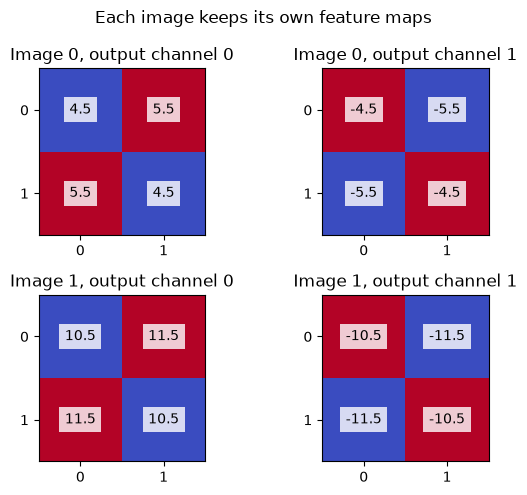

In [24]:
fig_56, axes_56 = plt.subplots(2, 2, figsize=(6, 5))
for batch_56 in range(2):
    for out_channel_56 in range(2):
        show_matrix(
            axes_56[batch_56, out_channel_56],
            y_batch_56[batch_56, out_channel_56],
            f"Image {batch_56}, output channel {out_channel_56}",
            cmap="coolwarm",
        )
fig_56.suptitle("Each image keeps its own feature maps")
plt.tight_layout()
plt.show()

## 56.4 プーリング：局所領域を代表値へまとめる

プーリングは小領域から代表値を取り出し、特徴マップの縦横を縮める演算である。最大値を取る **Max pooling** と、平均を取る **Average pooling** がある。

$$y^{\mathrm{max}}_{n,c,i,j}=\max_{u,v}x_{n,c,iS+u,jS+v}$$

$$y^{\mathrm{avg}}_{n,c,i,j}=\frac{1}{K_HK_W}\sum_{u,v}x_{n,c,iS+u,jS+v}$$

畳み込みと異なり、通常のプーリングは**チャネルごとに独立**に計算する。学習する重み・バイアスはなく、チャネル数も変えない。以下は $2\times2$ の領域をストライド 2 でまとめる例である。

実装では式の対応を分かりやすくするため、正方形の領域とパディングなしに限定する。出力サイズには、畳み込みと同じ計算式を使える。

In [25]:
def pool2d_nchw_array(x, kernel_size=2, stride=2, mode="max"):
    """正方形の窓・パディングなしの説明用プーリング。"""
    if mode not in ("max", "average"):
        raise ValueError("mode は 'max' または 'average' です")
    if kernel_size < 1 or stride < 1:
        raise ValueError("kernel_size と stride は 1 以上にしてください")
    n, channels, height, width = x.shape
    oh = get_conv_outsize(height, kernel_size, stride, 0)
    ow = get_conv_outsize(width, kernel_size, stride, 0)
    if min(oh, ow) < 1:
        raise ValueError("プーリング領域が入力より大きすぎます")
    y = np.zeros((n, channels, oh, ow), dtype=np.result_type(x, np.float32))
    for row in range(oh):
        for col in range(ow):
            top, left = row * stride, col * stride
            patch = x[:, :, top:top + kernel_size, left:left + kernel_size]
            # ★ Step 56：空間の軸だけを集約し、N と C の軸を残す
            if mode == "max":
                y[:, :, row, col] = patch.max(axis=(2, 3))
            else:
                y[:, :, row, col] = patch.mean(axis=(2, 3))
    return y

In [26]:
pool_image_56 = np.array([
    [1, 3, 2, 0],
    [4, 6, 5, 1],
    [2, 1, 3, 4],
    [0, 2, 1, 8],
], dtype=np.float64)
pool_input_56 = np.stack([pool_image_56, pool_image_56 + 10])[None, ...]
max_output_56 = pool2d_nchw_array(pool_input_56, mode="max")
avg_output_56 = pool2d_nchw_array(pool_input_56, mode="average")

print("input shape:", pool_input_56.shape)
print("max pooling shape:", max_output_56.shape)
print("channel 0, max:\n", max_output_56[0, 0])
print("channel 0, average:\n", avg_output_56[0, 0])
np.testing.assert_allclose(max_output_56[0, 0], [[6, 5], [2, 8]])
np.testing.assert_allclose(avg_output_56[0, 0], [[3.5, 2], [1.25, 4]])
np.testing.assert_allclose(max_output_56[:, 1], max_output_56[:, 0] + 10)
np.testing.assert_allclose(avg_output_56[:, 1], avg_output_56[:, 0] + 10)
assert max_output_56.shape == avg_output_56.shape == (1, 2, 2, 2)

input shape: (1, 2, 4, 4)
max pooling shape: (1, 2, 2, 2)
channel 0, max:
 [[6. 5.]
 [2. 8.]]
channel 0, average:
 [[3.5  2.  ]
 [1.25 4.  ]]


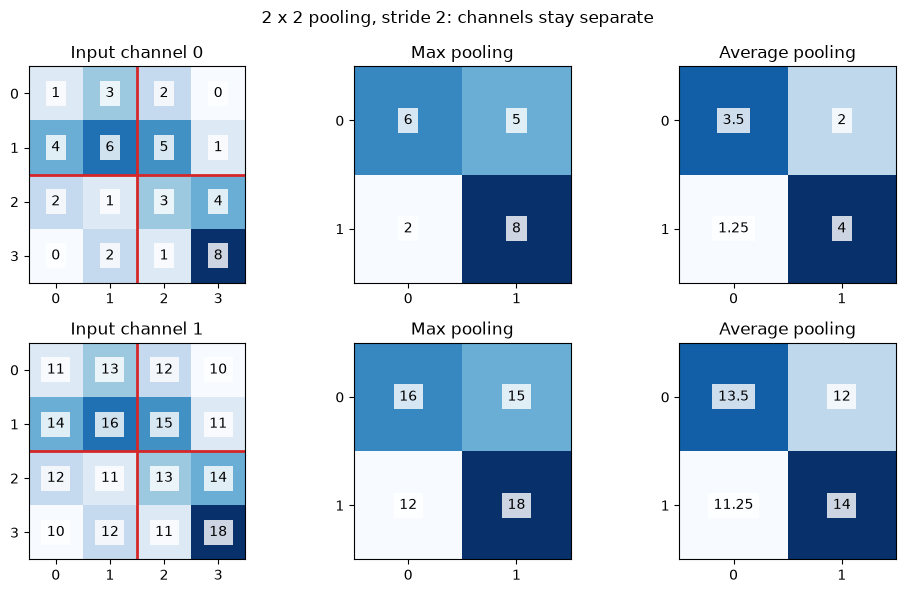

In [27]:
fig_56, axes_56 = plt.subplots(2, 3, figsize=(10, 6))
for channel_56 in range(2):
    show_matrix(axes_56[channel_56, 0], pool_input_56[0, channel_56],
                f"Input channel {channel_56}")
    axes_56[channel_56, 0].axhline(1.5, color="tab:red", linewidth=2)
    axes_56[channel_56, 0].axvline(1.5, color="tab:red", linewidth=2)
    show_matrix(axes_56[channel_56, 1], max_output_56[0, channel_56], "Max pooling")
    show_matrix(axes_56[channel_56, 2], avg_output_56[0, channel_56], "Average pooling")
fig_56.suptitle("2 x 2 pooling, stride 2: channels stay separate")
plt.tight_layout()
plt.show()

## 56.5 形状とパラメータ数を追跡する

$32\times32$ の RGB 画像を 2 枚まとめ、$3\times3$ のフィルタ 16 個で畳み込み、そのあとにプーリングを置く場合を考える。畳み込みはストライド 1・パディング 1、プーリングは領域 $2\times2$・ストライド 2・パディングなしとする。

| 処理 | 出力の形状 | 学習可能なパラメータ数 |
|---|---|---|
| 入力 | $(2,3,32,32)$ | 0 |
| 畳み込み | $(2,16,32,32)$ | $16\times3\times3\times3+16=448$ |
| ReLU | $(2,16,32,32)$ | 0 |
| Max pooling | $(2,16,16,16)$ | 0 |
| 平坦化 | $(2,4096)$ | 0 |
| 全結合層：10 クラス | $(2,10)$ | $4096\times10+10=40970$ |

**平坦化ではバッチ軸を残す**。各画像の $C\times H\times W$ だけを 1 次元へまとめる。この例では、最後の全結合層の方が畳み込み層より多くのパラメータを持つ。

In [28]:
batch_size_56, in_channels_56, image_size_56 = 2, 3, 32
out_channels_56, kernel_size_56 = 16, 3
conv_size_56 = get_conv_outsize(image_size_56, kernel_size_56, 1, 1)
pool_size_56 = get_conv_outsize(conv_size_56, 2, 2, 0)
flat_size_56 = out_channels_56 * pool_size_56 * pool_size_56
conv_parameters_56 = out_channels_56 * in_channels_56 * kernel_size_56 ** 2 + out_channels_56
linear_parameters_56 = flat_size_56 * 10 + 10

print("after conv:", (batch_size_56, out_channels_56, conv_size_56, conv_size_56))
print("after pool:", (batch_size_56, out_channels_56, pool_size_56, pool_size_56))
print("after flatten:", (batch_size_56, flat_size_56))
print("conv parameters:", conv_parameters_56)
print("linear parameters:", linear_parameters_56)
assert (conv_size_56, pool_size_56, flat_size_56) == (32, 16, 4096)
assert (conv_parameters_56, linear_parameters_56) == (448, 40970)

after conv: (2, 16, 32, 32)
after pool: (2, 16, 16, 16)
after flatten: (2, 4096)
conv parameters: 448
linear parameters: 40970


## 56.6 CNN の典型的な流れ

```text
(N, C, H, W)
      │
      ▼
 Convolution → ReLU → Pooling    局所的な特徴を抽出・集約
      │                         必要に応じて繰り返す
      ▼
   Flatten → Linear             各画像の特徴からクラスのスコアを作る
      │
      ▼
 (N, number_of_classes)
```

畳み込みで特徴を取り出し、ReLU で非線形性を入れ、プーリングで空間サイズを縮める。プーリングは、同じ小領域内での特徴の位置変化に対する感度を下げることがある。ただし領域の境界をまたぐ移動などでは値が変わるため、あらゆる位置ずれに不変になるわけではない。

ここでは順伝播の数値と形状を確認した。実際に CNN を学習するには畳み込み・プーリングの逆伝播も必要であり、続くステップで DeZero の `Function` として実装していく。リポジトリの完成版は `dezero/functions_conv.py` にまとまっている。

> **ステップ 56 のまとめ**
>
> - 1 個のフィルタは入力の全チャネルを参照し、その寄与を合算する。
> - フィルタ数が出力チャネル数になり、重みの形状は $(O_C,C,K_H,K_W)$ である。
> - バッチを含む入出力は NCHW で扱い、同じ重みを各画像へ適用する。
> - プーリングはチャネルごとに空間領域を集約し、学習可能なパラメータを持たない。
> - CNN の設計では、各層の出力形状とパラメータ数を区別して追跡する。

---
# 発展：DeZero と PyTorch の対応

前回と同様に、今回の機能を PyTorch の表現と対応付ける。ここは API の対応を読む補足なので、PyTorch のインストールは不要である。

| 役割 | DeZero | PyTorch |
|---|---|---|
| GPU へ移す | `model.to_gpu()`、`cuda.as_cupy(x)` | `model.to("cuda")`、`x.to("cuda")` |
| 重みを保存する | `model.save_weights(path)` | `torch.save(model.state_dict(), path)` |
| 重みを読み込む | `model.load_weights(path)` | `model.load_state_dict(torch.load(path, weights_only=True))` |
| Dropout | `F.dropout(x, dropout_ratio=p)` | `nn.Dropout(p)` |
| 推論時の振る舞い | `with test_mode():` | `model.eval()` |
| 学習時の振る舞い | `with` を抜けると元の設定へ戻る | `model.train()` |
| 計算グラフを作らない | `with no_grad():` | `with torch.no_grad():` |
| 2 次元畳み込み層 | `L.Conv2d(out_channels, kernel_size, ...)`（次回） | `nn.Conv2d(in_channels, out_channels, kernel_size, ...)` |
| 最大プーリング | `F.pooling(x, kernel_size, stride, ...)`（次回） | `nn.MaxPool2d(kernel_size, stride, ...)` |

DeZero の `test_mode()` は一時的なグローバル設定、PyTorch の `model.eval()` はそのモデルと子モジュールの設定であり、適用範囲と元へ戻す方法が異なる。どちらでも、推論時の振る舞いを選ぶ操作と勾配計算を止める操作は分かれている。


---
# まとめ ― 第 5 ステージ前半（ステップ 52 〜 56）

| ステップ | 追加した考え方 | Notebook で確認したこと |
|---|---|---|
| 52 | 計算デバイスの切り替え | 配列モジュールの選択、自動微分と学習ループ、経過時間 |
| 53 | 学習結果の再利用 | 名前付きの重み保存、別モデルへの復元、予測の一致 |
| 54 | 学習と推論の区別 | Dropout のマスクと勾配、スケール、2 種類のモード |
| 55 | 画像の局所領域を使う演算 | 2 次元畳み込み、パディング、ストライド、出力サイズ |
| 56 | 多次元の画像をまとめて処理 | チャネルとバッチ、複数フィルタ、プーリング |

### 理解を確かめる問い

1. 入力を GPU に移しただけでは不十分なのはなぜか。
2. `.npz` の重みだけを受け取ったとき、モデルを再現するためにほかに何が必要か。
3. `no_grad()` だけで Dropout の出力が毎回変わらなくなるか。
4. $H=W=8$、$K_H=K_W=3$、$S=2$、$P=1$ の畳み込みの出力サイズはいくつか。
5. 入力チャネルが 3、出力チャネルが 16、カーネルが $3\times3$ のとき、バイアス込みのパラメータ数はいくつか。

<details>
<summary>答えの確認</summary>

1. 入力・ラベル・パラメータのデバイスをそろえる必要がある。
2. ネットワークの構造、活性化関数、入力の前処理など。学習状態を完全に再現するには Optimizer や乱数の状態も必要である。
3. ならない。`no_grad()` は計算グラフ作成を止めるだけで、Dropout を止めるには `test_mode()` を使う。
4. 高さ・幅ともに `(8 + 2 - 3) // 2 + 1 = 4` なので $4\times4$。
5. $16\times3\times3\times3+16=448$ 個。

</details>

### 次のステップ（57 以降）

今回は小さな配列で CNN の計算を追った。次回は `im2col` などを使い、畳み込みを行列演算として実装し、DeZero の自動微分と組み合わせる。GPU・保存・推論モードという前半の機能は、CNN でもそのまま使う。

### 対応するリポジトリのコード

- [step52.py](../steps/step52.py)、[step53.py](../steps/step53.py)、[step54.py](../steps/step54.py)：GPU 学習・重み保存・Dropout の使用例。
- [step55.py](../steps/step55.py)：畳み込みの出力サイズ。[step56.py](../steps/step56.py) はコードなしのため、本 Notebook では仕組みを確認する NumPy の例を補っている。
- [cuda.py](../dezero/cuda.py)、[core.py](../dezero/core.py)、[dataloaders.py](../dezero/dataloaders.py)：デバイス切り替えと設定管理。
- [layers.py](../dezero/layers.py)、[functions.py](../dezero/functions.py)：重みの保存・読込と Dropout。
- [functions_conv.py](../dezero/functions_conv.py)：後続ステップで扱う畳み込み・プーリングの実装。
